# L07 — Gradients

**Module 1 · Day 9 of the roadmap**  
Companion notebook to `L07_summary.md`. Run cells top to bottom.

By the end of this notebook you'll be able to:
1. Compute Larmor frequencies in the presence of a gradient.
2. Visualize the ideal gradient field for x, y, z, and oblique directions.
3. See **constant-frequency planes** for any gradient vector.
4. Check Maxwell's divergence violation symbolically.
5. Compute the **concomitant (Maxwell) field** from the explicit formula.
6. Compare $B_\mathrm{CC}$ between low-field and high-field scanners.

We use synthetic data only — no datasets needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (8, 5)

# Physical constants
GAMMA = 2.675e8           # rad / (s·T) — proton gyromagnetic ratio
GAMMA_BAR = GAMMA / (2 * np.pi)   # Hz / T  (≈ 42.58 MHz/T)
print(f'gamma     = {GAMMA:.3e} rad/(s·T)')
print(f'gamma/2pi = {GAMMA_BAR/1e6:.2f} MHz/T')

gamma     = 2.675e+08 rad/(s·T)
gamma/2pi = 42.57 MHz/T


## 1. Larmor frequency in the presence of a gradient

$$\omega(\boldsymbol r) = \gamma\bigl(B_0 + \boldsymbol G \cdot \boldsymbol r\bigr)$$

Equivalently, frequency offset from isocenter: $\Delta f(\boldsymbol r) = (\gamma / 2\pi)\, \boldsymbol G\cdot \boldsymbol r$.

In [2]:
def larmor_frequency(B0, G, r):
    """Return Larmor frequency in Hz at position r given gradient G and main field B0.
    All inputs in SI units (T, T/m, m)."""
    G = np.asarray(G, dtype=float)
    r = np.asarray(r, dtype=float)
    B_total = B0 + np.dot(G, r)
    return GAMMA_BAR * B_total

# Reproduce Exercise 1 from the summary:
# B0 = 3 T, Gx = 20 mT/m, proton at x = 10 cm
B0 = 3.0
G = (0.020, 0.0, 0.0)     # 20 mT/m along x
r_iso = (0.0, 0.0, 0.0)
r_edge = (0.10, 0.0, 0.0)

f_iso = larmor_frequency(B0, G, r_iso)
f_edge = larmor_frequency(B0, G, r_edge)

print(f'f at isocenter   : {f_iso/1e6:.3f} MHz')
print(f'f at x = 10 cm   : {f_edge/1e6:.3f} MHz')
print(f'difference       : {(f_edge - f_iso)/1e3:.1f} kHz')

f at isocenter   : 127.722 MHz
f at x = 10 cm   : 127.807 MHz
difference       : 85.1 kHz


**Sanity check:** $\Delta f = (\gamma/2\pi)\,G_x\,x = 42.58\text{ MHz/T} \times 0.020\text{ T/m} \times 0.10\text{ m} \approx 85.2$ kHz. ✓

**Across a 25 cm FOV with that gradient:**

In [3]:
FOV = 0.25                # 25 cm
Gx = 0.020                # 20 mT/m
df_total = GAMMA_BAR * Gx * FOV
print(f'Peak-to-peak frequency spread across the FOV: {df_total/1e3:.1f} kHz')
print(f'Receiver bandwidth must exceed this.')

Peak-to-peak frequency spread across the FOV: 212.9 kHz
Receiver bandwidth must exceed this.


## 2. Visualizing the ideal gradient field

Ideal: $\boldsymbol B_\mathrm{G,ideal}(\boldsymbol r) = (\boldsymbol G \cdot \boldsymbol r)\,\hat{\boldsymbol e}_z$ — purely along $z$, varying linearly with position.

Each arrow in the plot below is the **gradient field at that point** (i.e., the *additional* field on top of $B_0$). Arrow direction is always $\pm\hat{\boldsymbol e}_z$ in the ideal case; arrow length is proportional to $\lvert\boldsymbol G \cdot \boldsymbol r\rvert$. Dashed lines mark constant-$B$ planes (= constant Larmor frequency).

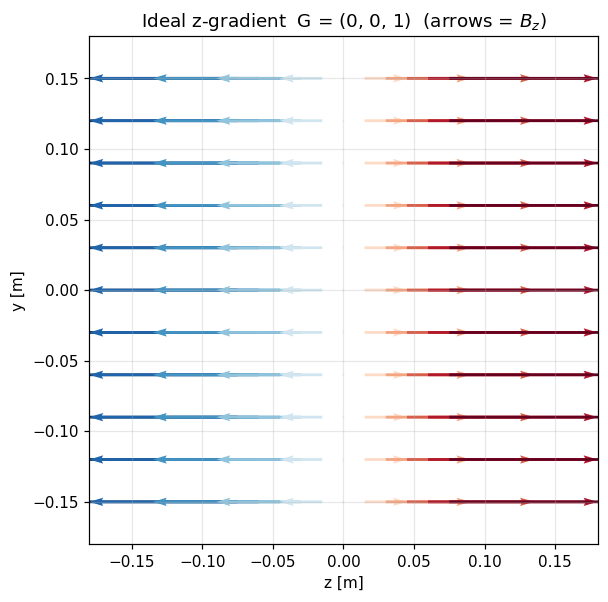

In [4]:
def plot_ideal_gradient_2d(G, title=None, extent=0.15, n=11):
    """Plot the z-component of the ideal gradient field on a y–z slice (x=0).
    Arrows along +/- z direction, scaled by magnitude of G·r."""
    G = np.asarray(G, dtype=float)
    yy, zz = np.meshgrid(np.linspace(-extent, extent, n),
                         np.linspace(-extent, extent, n), indexing='ij')
    xx = np.zeros_like(yy)
    Bz = G[0]*xx + G[1]*yy + G[2]*zz       # gradient field z-component
    
    fig, ax = plt.subplots(figsize=(6, 6))
    # Plot arrows along z (vertical in this view)
    ax.quiver(zz, yy, Bz, np.zeros_like(Bz), Bz,
              angles='xy', scale_units='xy', scale=1.0,
              cmap='RdBu_r', pivot='middle')
    ax.set_xlabel('z [m]'); ax.set_ylabel('y [m]')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    if title: ax.set_title(title)
    ax.set_xlim(-extent*1.2, extent*1.2)
    ax.set_ylim(-extent*1.2, extent*1.2)
    return fig

# Pure z-gradient: field magnitude depends only on z
plot_ideal_gradient_2d((0, 0, 1.0), title='Ideal z-gradient  G = (0, 0, 1)  (arrows = $B_z$)')
plt.show()

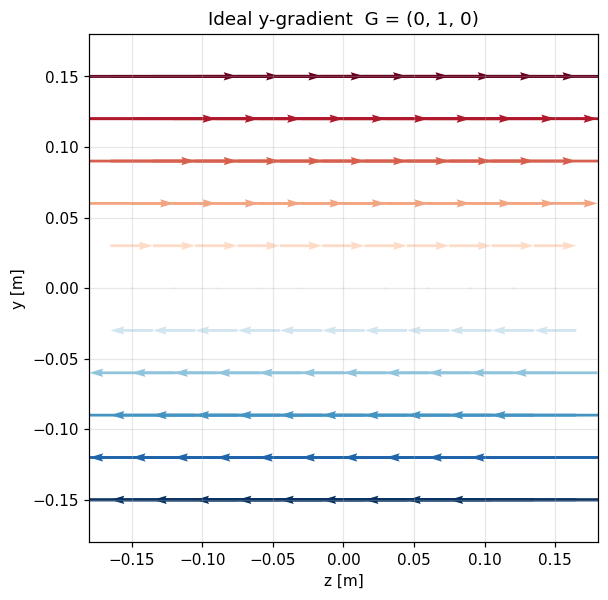

In [5]:
# Pure y-gradient: field magnitude depends only on y
plot_ideal_gradient_2d((0, 1.0, 0), title='Ideal y-gradient  G = (0, 1, 0)')
plt.show()

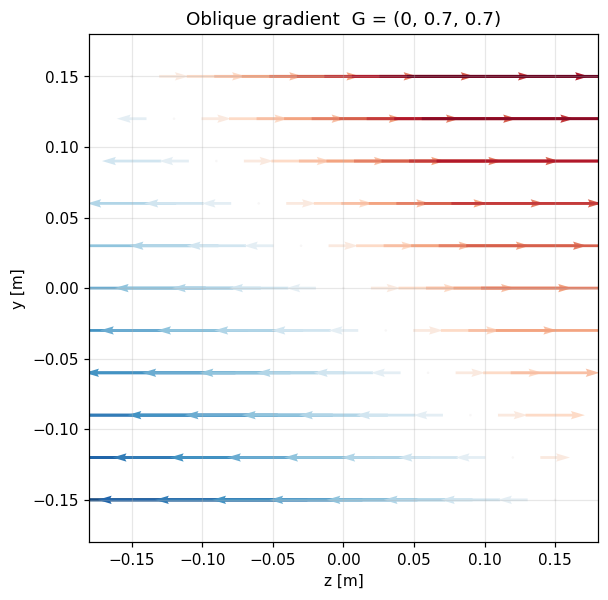

In [6]:
# Oblique gradient: G has both y and z components
plot_ideal_gradient_2d((0, 0.7, 0.7), title='Oblique gradient  G = (0, 0.7, 0.7)')
plt.show()

## 3. Constant-frequency planes are perpendicular to G

Plot $\boldsymbol G \cdot \boldsymbol r$ as a 2D scalar field and draw its contour lines. The lines are exactly the **constant-frequency surfaces** — perpendicular to $\boldsymbol G$.

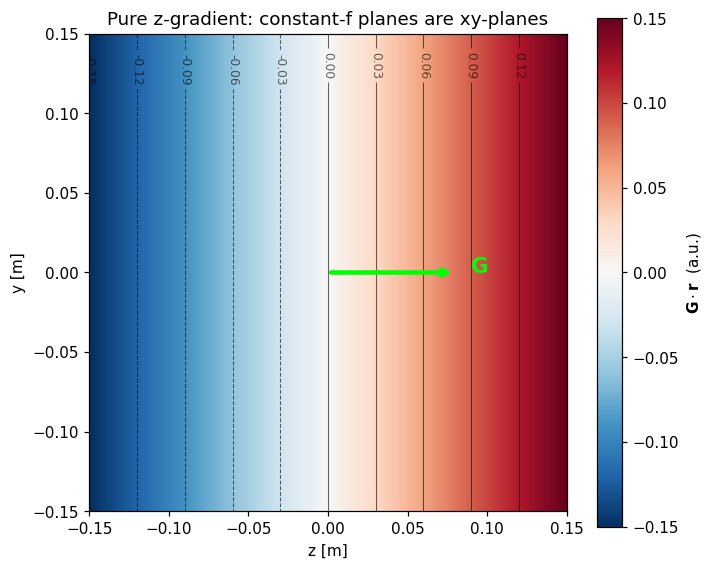

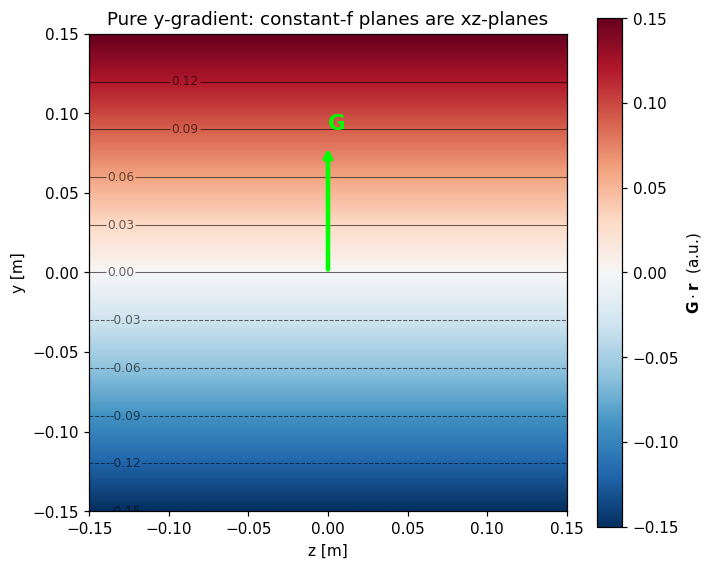

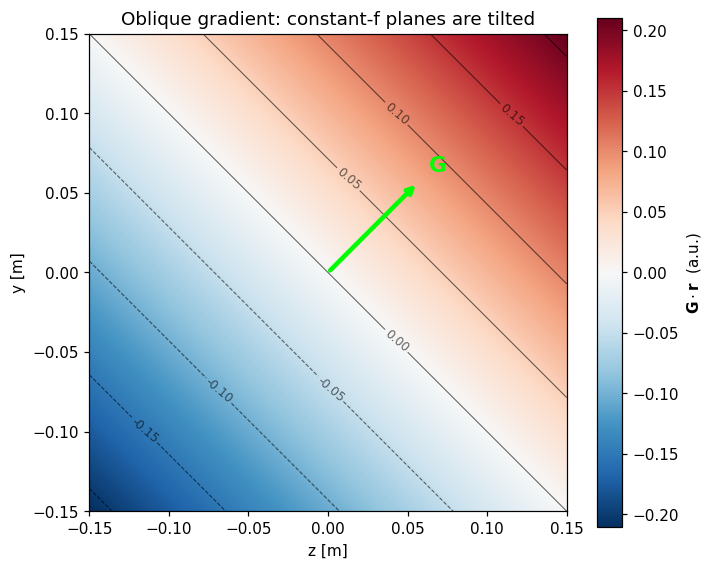

In [7]:
def plot_constant_frequency_planes(G, title=None, extent=0.15, n=200):
    G = np.asarray(G, dtype=float)
    yy, zz = np.meshgrid(np.linspace(-extent, extent, n),
                         np.linspace(-extent, extent, n), indexing='ij')
    field = G[1]*yy + G[2]*zz          # x=0 slice
    
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(field, origin='lower', cmap='RdBu_r',
                   extent=[-extent, extent, -extent, extent])
    cs = ax.contour(zz, yy, field, levels=9, colors='k', linewidths=0.7, alpha=0.6)
    ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')
    # Draw the gradient vector at the origin
    norm = np.linalg.norm([G[2], G[1]])
    if norm > 0:
        ax.annotate('', xy=(0.08*G[2]/norm, 0.08*G[1]/norm), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='lime', lw=3))
        ax.text(0.09*G[2]/norm, 0.09*G[1]/norm, 'G', color='lime', fontsize=14, fontweight='bold')
    ax.set_xlabel('z [m]'); ax.set_ylabel('y [m]')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, label=r'$\mathbf{G}\cdot\mathbf{r}$  (a.u.)')
    if title: ax.set_title(title)
    return fig

plot_constant_frequency_planes((0, 0, 1.0), title='Pure z-gradient: constant-f planes are xy-planes')
plot_constant_frequency_planes((0, 1.0, 0),  title='Pure y-gradient: constant-f planes are xz-planes')
plot_constant_frequency_planes((0, 0.7, 0.7), title='Oblique gradient: constant-f planes are tilted')
plt.show()

**Key observation.** In all three plots, the contour lines are **perpendicular to the gradient vector $\boldsymbol G$**. This is exactly why you can pick any slice orientation in MRI: just point $\boldsymbol G$ in the desired normal direction.

## 4. Maxwell catches the textbook gradient (symbolically)

The ideal gradient field is $\boldsymbol B_\mathrm{G,ideal} = (xG_x + yG_y + zG_z)\,\hat{\boldsymbol e}_z$. Let's verify symbolically that $\nabla\cdot\boldsymbol B_\mathrm{G,ideal} = G_z$.

In [10]:
import sympy as sp

x, y, z, Gx, Gy, Gz = sp.symbols('x y z G_x G_y G_z', real=True)
B_ideal = sp.Matrix([0, 0, x*Gx + y*Gy + z*Gz])

div_B = sp.diff(B_ideal[0], x) + sp.diff(B_ideal[1], y) + sp.diff(B_ideal[2], z)
print('div B_ideal =', div_B)
print()
print('Maxwell requires div B = 0, but we got G_z.')
print('So whenever G_z != 0, the ideal field is unphysical. ∎')

div B_ideal = G_z

Maxwell requires div B = 0, but we got G_z.
So whenever G_z != 0, the ideal field is unphysical. ∎


## 5. The concomitant (Maxwell) field

Explicit formula:
$$B_\mathrm{CC}(\boldsymbol r) = \frac{1}{2 B_0}\left[\frac{G_z^2(x^2+y^2)}{4} + z^2(G_x^2 + G_y^2) - x z\, G_z G_x - y z\, G_z G_y\right]$$

In [11]:
def concomitant_field(B0, G, r):
    """Concomitant (Maxwell) field magnitude at position r.
    Returns B_CC in T. Inputs in SI units."""
    G = np.asarray(G, dtype=float)
    r = np.asarray(r, dtype=float)
    Gx, Gy, Gz = G
    x, y, z = r
    term = (Gz**2 * (x**2 + y**2) / 4
            + z**2 * (Gx**2 + Gy**2)
            - x*z * Gz*Gx
            - y*z * Gz*Gy)
    return term / (2 * B0)

# Reproduce Exercise 5 from the summary:
B0 = 1.5
G = (0.030, 0.0, 0.0)   # 30 mT/m along x
for r in [(0.10, 0, 0), (0, 0, 0.10), (0, 0, 0.20)]:
    B_cc = concomitant_field(B0, G, r)
    print(f'r = {r} m   ->   B_CC = {B_cc*1e6:.3f} μT   (= {B_cc/B0*1e6:.2f} ppm of B0)')

r = (0.1, 0, 0) m   ->   B_CC = 0.000 μT   (= 0.00 ppm of B0)
r = (0, 0, 0.1) m   ->   B_CC = 3.000 μT   (= 2.00 ppm of B0)
r = (0, 0, 0.2) m   ->   B_CC = 12.000 μT   (= 8.00 ppm of B0)


**Notice:** at $\boldsymbol r = (0.10, 0, 0)$ — on the gradient's own axis with $z = 0$ — the CC field is *exactly zero*. Move 10 cm along $z$ and it jumps to ~3 μT. The CC field lives **off-axis**.

Now visualize $B_\mathrm{CC}$ over a 2D slice:

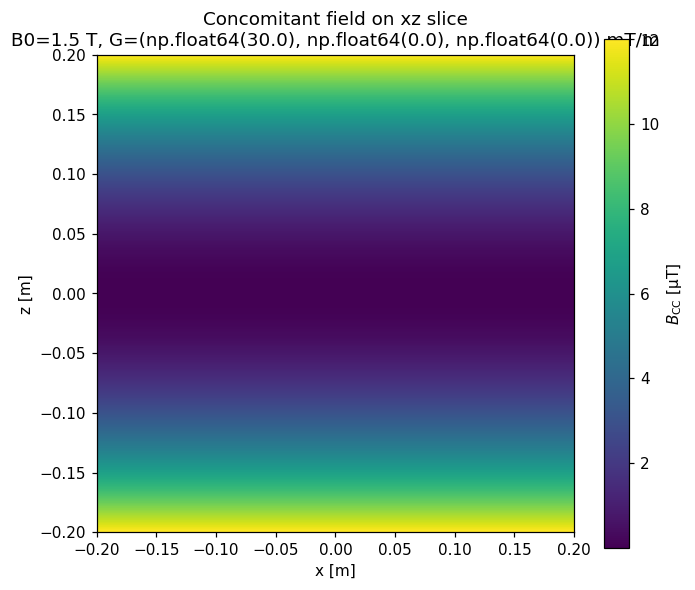

In [12]:
def plot_BCC_slice(B0, G, plane='xz', extent=0.20, n=200):
    """Plot B_CC on a 2D slice through the isocenter."""
    G = np.asarray(G, dtype=float); Gx, Gy, Gz = G
    coord = np.linspace(-extent, extent, n)
    A, B = np.meshgrid(coord, coord, indexing='ij')
    if plane == 'xz':
        x, y, z = A, np.zeros_like(A), B
        axlabels = ('x [m]', 'z [m]')
    elif plane == 'xy':
        x, y, z = A, B, np.zeros_like(A)
        axlabels = ('x [m]', 'y [m]')
    elif plane == 'yz':
        x, y, z = np.zeros_like(A), A, B
        axlabels = ('y [m]', 'z [m]')
    term = (Gz**2 * (x**2 + y**2) / 4
            + z**2 * (Gx**2 + Gy**2)
            - x*z * Gz*Gx
            - y*z * Gz*Gy)
    B_cc = term / (2 * B0)
    
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(B_cc.T * 1e6, origin='lower',
                   extent=[-extent, extent, -extent, extent],
                   cmap='viridis', aspect='equal')
    ax.set_xlabel(axlabels[0]); ax.set_ylabel(axlabels[1])
    plt.colorbar(im, ax=ax, label=r'$B_\mathrm{CC}$ [μT]')
    ax.set_title(f'Concomitant field on {plane} slice\nB0={B0} T, G={tuple(g*1000 for g in G)} mT/m')
    return fig

# Gx only: CC field grows with z, not with x. The xz-slice shows this clearly.
plot_BCC_slice(B0=1.5, G=(0.030, 0, 0), plane='xz')
plt.show()

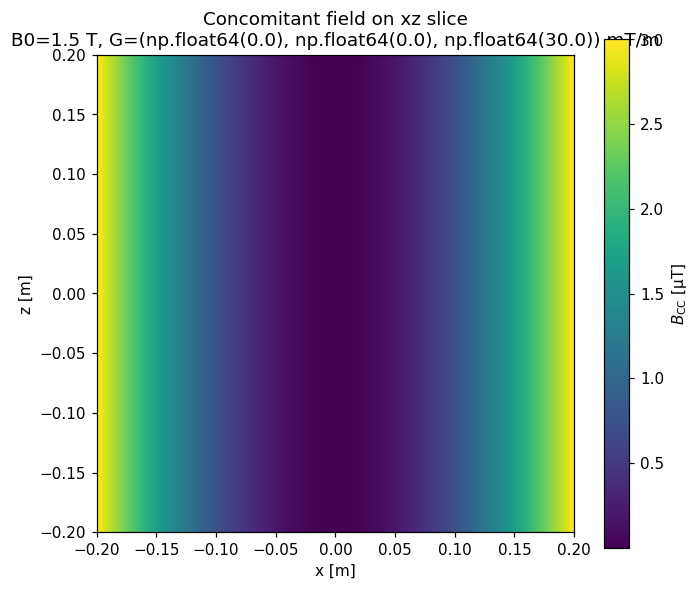

In [13]:
# Now switch on Gz only: the structure is completely different.
plot_BCC_slice(B0=1.5, G=(0, 0, 0.030), plane='xz')
plt.show()

**Notice the structural difference:**
- With $G_x$ only, $B_\mathrm{CC} \propto z^2$ — quadratic stripes along $z$, independent of $x$.
- With $G_z$ only, $B_\mathrm{CC} \propto (x^2+y^2)/4$ — radial growth in the $xy$-plane, independent of $z$ on this slice (so it looks flat at $y=0$).

These different geometries are why CC corrections are sequence-specific.

## 6. Why low-field MRI suffers more

$B_\mathrm{CC} \propto 1/B_0$, so doubling the field halves the CC field. Let's quantify.

In [14]:
B0_values = np.array([0.5, 1.5, 3.0, 7.0])
G = (0.030, 0, 0)               # 30 mT/m along x
r = (0, 0, 0.10)                # 10 cm off-axis along z

print(f'{"B0 [T]":>8}   {"B_CC [μT]":>10}   {"B_CC / B0 [ppm]":>17}')
print('-' * 42)
for B0 in B0_values:
    B_cc = concomitant_field(B0, G, r)
    print(f'{B0:>8.1f}   {B_cc*1e6:>10.3f}   {B_cc/B0*1e6:>17.3f}')

  B0 [T]    B_CC [μT]     B_CC / B0 [ppm]
------------------------------------------
     0.5        9.000              18.000
     1.5        3.000               2.000
     3.0        1.500               0.500
     7.0        0.643               0.092


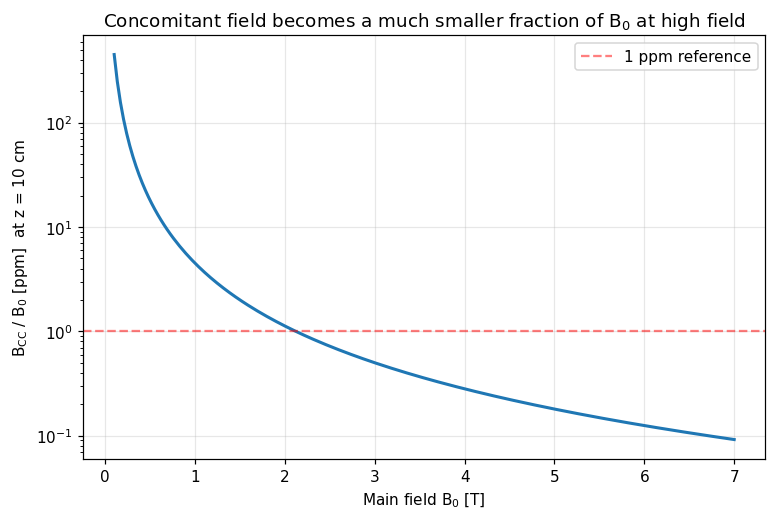

In [15]:
# Plot: B_CC / B0 (in ppm) vs B0
B0_range = np.linspace(0.1, 7.0, 200)
B_cc_vals = np.array([concomitant_field(b, G, r) for b in B0_range])

fig, ax = plt.subplots()
ax.plot(B0_range, B_cc_vals / B0_range * 1e6, lw=2)
ax.set_xlabel('Main field B$_0$ [T]')
ax.set_ylabel('B$_\\mathrm{CC}$ / B$_0$ [ppm]  at z = 10 cm')
ax.set_title('Concomitant field becomes a much smaller fraction of B$_0$ at high field')
ax.grid(alpha=0.3); ax.set_yscale('log')
ax.axhline(1.0, color='red', ls='--', alpha=0.5, label='1 ppm reference')
ax.legend(); plt.show()

## 7. Sign trick fails for concomitant fields

A common MRI trick: cancel the phase from $+G$ by applying $-G$ for the same time. Works for the *linear* phase, but **fails for the concomitant phase** because $B_\mathrm{CC} \propto G^2$.

In [16]:
B0 = 1.5
r = (0, 0, 0.05)        # 5 cm off-axis
duration = 1e-3         # 1 ms gradient pulse

G_positive = (0.030, 0, 0)
G_negative = (-0.030, 0, 0)

# Phase from linear gradient (∝ G·r)
phi_pos_lin = GAMMA * np.dot(G_positive, r) * duration
phi_neg_lin = GAMMA * np.dot(G_negative, r) * duration
print(f'Linear phase from +G:  {phi_pos_lin:+.4f} rad')
print(f'Linear phase from -G:  {phi_neg_lin:+.4f} rad')
print(f'Sum (linear)        :  {phi_pos_lin + phi_neg_lin:+.4f} rad   <- cancels ✓\n')

# Phase from concomitant field (∝ G²)
phi_pos_cc = GAMMA * concomitant_field(B0, G_positive, r) * duration
phi_neg_cc = GAMMA * concomitant_field(B0, G_negative, r) * duration
print(f'CC phase from +G    :  {phi_pos_cc:+.4e} rad')
print(f'CC phase from -G    :  {phi_neg_cc:+.4e} rad')
print(f'Sum (CC)            :  {phi_pos_cc + phi_neg_cc:+.4e} rad   <- ADDS UP — does NOT cancel ✗')

Linear phase from +G:  +0.0000 rad
Linear phase from -G:  +0.0000 rad
Sum (linear)        :  +0.0000 rad   <- cancels ✓

CC phase from +G    :  +2.0063e-01 rad
CC phase from -G    :  +2.0063e-01 rad
Sum (CC)            :  +4.0125e-01 rad   <- ADDS UP — does NOT cancel ✗


**This is exactly why sequences sensitive to small phase errors** (phase-contrast MRI, EPI, spiral) need explicit CC correction in reconstruction.

## Try it yourself

Pick at least two:

1. **Hot-spot finder.** For $B_0 = 1.5$ T and a simultaneous $G_x = G_y = G_z = 20$ mT/m, find the position within a 20 cm sphere where $B_\mathrm{CC}$ is largest. Use a coarse grid search.
2. **Off-axis slice.** Build a function `plot_oblique_slice(n_hat, ...)` that takes a unit-normal vector and a position, and plots the constant-frequency plane it defines.
3. **Time-varying gradient.** Make $G_x(t)$ a trapezoid (ramp up, plateau, ramp down) and animate (or just plot) the gradient field along the x-axis at three time points.
4. **Slew rate.** Modern scanners have a max slew rate of ~200 T/m/s. How fast can you ramp from 0 to 40 mT/m? Compare with EPI readout requirements.
5. **Compare to real scanners.** Look up the gradient specs for a current clinical 3 T scanner and a 7 T scanner. Compute the CC field at a typical anatomical location for each and discuss.

##  Recap

- A gradient $\boldsymbol G$ makes the Larmor frequency a **linear function of position**: $\omega(\boldsymbol r) = \gamma(B_0 + \boldsymbol G\cdot\boldsymbol r)$.
- The **ideal** gradient field points purely along $\hat{\boldsymbol e}_z$ to make the field *magnitude* linear.
- **Constant-frequency surfaces are planes perpendicular to $\boldsymbol G$** — this is what lets you pick any slice orientation.
- The ideal field **violates Maxwell** ($\nabla\cdot\boldsymbol B = G_z$), so the real field has transverse components.
- These transverse components contribute a **concomitant (Maxwell) field** $B_\mathrm{CC} = B_{\mathrm{G},\perp}^2 / (2B_0)$ — small, always positive, quadratic in $G$, inversely proportional to $B_0$, and not removable by sign-flipping tricks.
